# Homework 12: Stakeholder-Ready Risk-Alert Delivery

**Audience:** a portfolio risk manager deciding whether to request additional review before the next market open. The notebook is self-contained: it uses a small deterministic scenario table rather than external files.

## Executive summary

- The baseline alert captures about half of simulated high-volatility days, so it is suitable only as a human review trigger.
- A stricter cutoff reduces review workload but misses more high-volatility days.
- Recommendation: retain the baseline for manual review and monitor missed events by market regime.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {"Baseline (0.52)": "#2563EB", "Conservative (0.70)": "#D97706"}
reports = Path("reports")
images = reports / "images"
images.mkdir(parents=True, exist_ok=True)

scenarios = pd.DataFrame({
    "scenario": ["Baseline (0.52)", "Conservative (0.70)"],
    "cutoff": [0.52, 0.70],
    "recall": [0.486, 0.257],
    "alert_rate": [0.140, 0.058],
    "precision": [0.243, 0.310],
    "captured": [17, 9],
    "missed": [18, 26],
})
scenarios

,scenario,cutoff,recall,alert_rate,precision,captured,missed
0,Baseline (0.52),0.52,0.486,0.140,0.243,17,18
1,Conservative (0.70),0.70,0.257,0.058,0.310,9,26


## Chart 1 - Event capture by scenario

This bar chart compares the share of high-volatility days captured. The baseline catches more events; the conservative rule reduces the chance that a risk manager sees a relevant day.

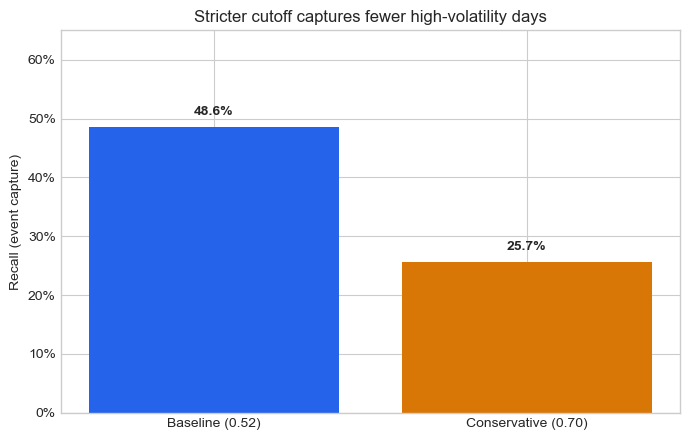

In [2]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(scenarios["scenario"], scenarios["recall"], color=[COLORS[x] for x in scenarios["scenario"]])
ax.set(title="Stricter cutoff captures fewer high-volatility days", ylabel="Recall (event capture)", ylim=(0, 0.65))
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
for i, value in enumerate(scenarios["recall"]):
    ax.text(i, value + 0.02, f"{value:.1%}", ha="center", weight="bold")
fig.tight_layout()
fig.savefig(images / "event_capture_by_cutoff.png", dpi=300, bbox_inches="tight")
plt.show()

## Chart 2 - Review workload versus cutoff

As the threshold rises, the review workload declines. This is not a free improvement: lower workload comes with lower event capture.

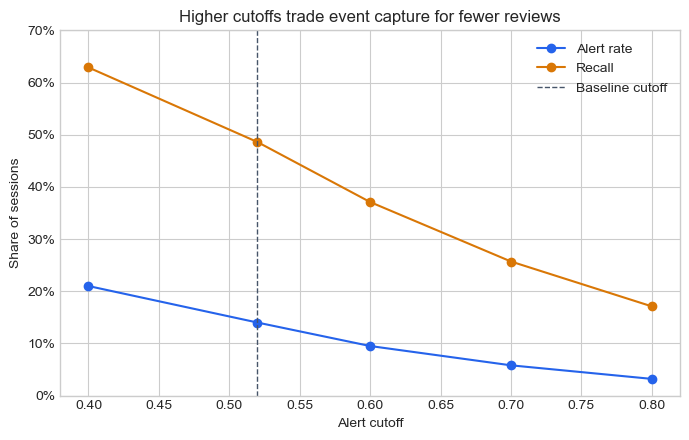

In [3]:
cutoff_curve = pd.DataFrame({
    "cutoff": [0.40, 0.52, 0.60, 0.70, 0.80],
    "alert_rate": [0.210, 0.140, 0.095, 0.058, 0.032],
    "recall": [0.629, 0.486, 0.371, 0.257, 0.171],
})
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(cutoff_curve["cutoff"], cutoff_curve["alert_rate"], marker="o", color="#2563EB", label="Alert rate")
ax.plot(cutoff_curve["cutoff"], cutoff_curve["recall"], marker="o", color="#D97706", label="Recall")
ax.axvline(0.52, color="#475569", ls="--", lw=1, label="Baseline cutoff")
ax.set(title="Higher cutoffs trade event capture for fewer reviews", xlabel="Alert cutoff", ylabel="Share of sessions", ylim=(0, 0.70))
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.legend()
fig.tight_layout()
fig.savefig(images / "review_workload_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

## Chart 3 - Workload and capture trade-off

The scatter plot shows the business trade-off directly. The baseline point has higher workload but better risk coverage; the conservative point is lighter operationally but creates more missed events.

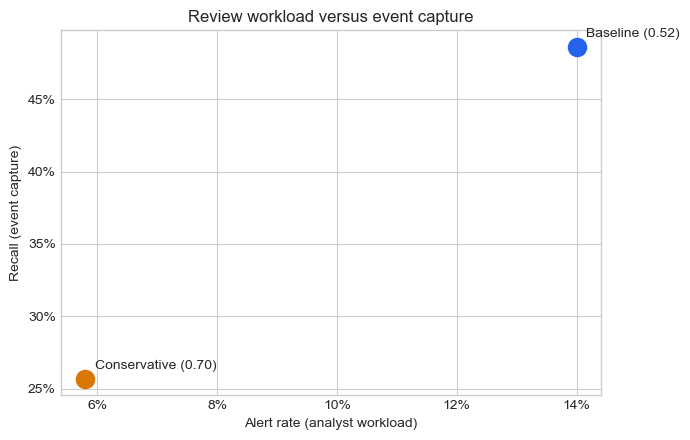

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for _, row in scenarios.iterrows():
    ax.scatter(row["alert_rate"], row["recall"], s=170, color=COLORS[row["scenario"]])
    ax.annotate(row["scenario"], (row["alert_rate"], row["recall"]), xytext=(7, 7), textcoords="offset points")
ax.set(title="Review workload versus event capture", xlabel="Alert rate (analyst workload)", ylabel="Recall (event capture)")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
fig.tight_layout()
fig.savefig(images / "workload_capture_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()

## Sensitivity summary and assumptions

The conservative cutoff moves alert rate from 14.0% to 5.8%, but recall falls from 48.6% to 25.7%. The outcome depends on stable market behavior, timely input data, and the assumption that a historical event definition remains useful. These simulated values illustrate the communication pattern; they are not a trading recommendation.

In [5]:
sensitivity = scenarios.assign(
    recall_delta=lambda x: x["recall"] - x.loc[0, "recall"],
    alert_rate_delta=lambda x: x["alert_rate"] - x.loc[0, "alert_rate"],
)[["scenario", "cutoff", "recall", "recall_delta", "alert_rate", "alert_rate_delta"]]
sensitivity

,scenario,cutoff,recall,recall_delta,alert_rate,alert_rate_delta
0,Baseline (0.52),0.52,0.486,0.000,0.140,0.000
1,Conservative (0.70),0.70,0.257,-0.229,0.058,-0.082


## Decision implications

- Use the baseline threshold to prioritize analyst review, not to trigger automatic action.
- If review capacity is constrained, decision-makers should explicitly accept the additional missed-event risk of the conservative threshold.
- Monitor false negatives, alert rate, data quality, and performance by volatility regime before changing the threshold.